In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# data loading and EDA

In [2]:
df = pd.read_csv('D:/downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
# Inspect the initial structure
print("Initial Dataset Info:")
df.info()

Initial Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  70

In [4]:
# Convert 'TotalCharges' to numeric, forcing hidden blank spaces to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [5]:
# Drop the rows with missing TotalCharges values
df.dropna(inplace=True)

In [6]:
# Drop 'customerID' as it holds no predictive value for the model
df.drop('customerID', axis=1, inplace=True)

In [7]:
# Calculate the exact churn percentages
churn_summary = df['Churn'].value_counts(normalize=True) * 100
print("\nChurn Percentage:")
print(churn_summary)


Churn Percentage:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


C:\Users\Hany\AppData\Local\Temp\ipykernel_24060\3847304997.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='mako')


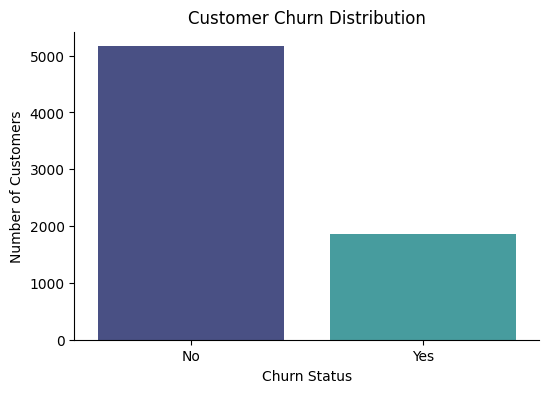

In [8]:
# Visualize the target variable distribution to check for class imbalance
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='mako')
plt.title('Customer Churn Distribution')
plt.ylabel('Number of Customers')
plt.xlabel('Churn Status')
sns.despine() # Minimalist plot styling
plt.show()